# 📱Feature Extraction and Price Prediction for Mobile Phones

# NextHikes IT Solutions : Mobile Phone Retail Pricing Analytics
# Deadline : 25 August 2026
# Project : 4th
# Developed by : Rashika Singh
## Complete Professional End-to-End Machine Learning Project



**Workflow:** EDA → Univariate Analysis → Distribution & Skewness → Categorical Analysis → Outlier Detection → Outlier Removal → Feature Extraction → Correlation → One-Hot Encoding → Model Building → Evaluation → Model Comparison → Residual Analysis → Feature Importance → Cross-Validation → Prediction → Business Recommendations

**Models:** Linear Regression, Decision Tree, Random Forest, Extra Trees, Gradient Boosting

**Metrics:** MAE, RMSE, R²


In [1]:
# ============================================================
# MOBILE PHONE PRICE PREDICTION — COMPLETE PROFESSIONAL PROJECT
# ============================================================

# 1. IMPORT LIBRARIES
import warnings
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from joblib import dump

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


# LOAD DATA

In [3]:
from google.colab import files
df = pd.read_csv("mobile_phone_dataset.csv")

In [63]:
print(df.shape)


(541, 12)


In [64]:
df.head()

,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,11999
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,5649
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,8999


In [4]:
# Remove unwanted Unnamed columns
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

Dataset shape: (541, 11)
Columns: ['Model', 'Colour', 'Memory', 'RAM', 'Battery_', 'Rear Camera', 'Front Camera', 'AI Lens', 'Mobile Height', 'Processor_', 'Prize']


,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,11999
3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,5649
4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,8999


# INITIAL DATA EXPLORATION

In [5]:
print("\nFIRST 5 ROWS")
display(df.head())


FIRST 5 ROWS


,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,11999
3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,5649
4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,8999


In [10]:
print("\nLAST 5 ROWS")
display(df.tail())


LAST 5 ROWS


,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
536,SAMSUNG Galaxy S23 5G,Cream,256,8,3900,50MP,12MP,0,15.49,Qualcomm Snapdragon 8 Gen 2,79999
537,LAVA Z21,Cyan,32,2,3100,5MP,2MP,0,12.70,Octa Core,5998
538,Tecno Spark 8T,Turquoise Cyan,64,4,5000,50MP,8MP,0,16.76,MediaTek Helio G35,9990
539,SAMSUNG Galaxy A54 5G,Awesome Lime,128,8,5000,50MP,32MP,0,16.26,"Exynos 1380, Octa Core",38999
540,OPPO A77,Sky Blue,128,4,5000,50MP,8MP,0,16.66,Mediatek Helio G35,15999


In [11]:
print("\nDATA INFORMATION")
df.info()


DATA INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Model          541 non-null    object 
 1   Colour         541 non-null    object 
 2   Memory         541 non-null    int64  
 3   RAM            541 non-null    int64  
 4   Battery_       541 non-null    int64  
 5   Rear Camera    541 non-null    object 
 6   Front Camera   541 non-null    object 
 7   AI Lens        541 non-null    int64  
 8   Mobile Height  541 non-null    float64
 9   Processor_     541 non-null    object 
 10  Prize          541 non-null    int64  
dtypes: float64(1), int64(5), object(5)
memory usage: 46.6+ KB


In [12]:
print("\nDESCRIPTIVE STATISTICS")
display(df.describe(include="all").T)


DESCRIPTIVE STATISTICS


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Model,541,187,realme C55,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Colour,541,275,Yellow,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Memory,541.0,NaN,NaN,NaN,110.550832,60.600694,16.0,64.0,128.0,128.0,256.0
RAM,541.0,NaN,NaN,NaN,5.397412,1.984923,2.0,4.0,6.0,8.0,8.0
Battery_,541.0,NaN,NaN,NaN,4871.5878,780.148862,800.0,5000.0,5000.0,5000.0,7000.0
Rear Camera,541,14,50MP,260,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Front Camera,541,13,16MP,164,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AI Lens,541.0,NaN,NaN,NaN,0.062847,0.242911,0.0,0.0,0.0,0.0,1.0
Mobile Height,541.0,NaN,NaN,NaN,16.431201,2.523553,4.5,16.51,16.71,16.94,41.94
Processor_,541,123,Qualcomm Snapdragon 680,33,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# MISSING VALUE ANALYSIS

,Missing_Count,Missing_Percentage
Model,0,0.0
Colour,0,0.0
Memory,0,0.0
RAM,0,0.0
Battery_,0,0.0
Rear Camera,0,0.0
Front Camera,0,0.0
AI Lens,0,0.0
Mobile Height,0,0.0
Processor_,0,0.0


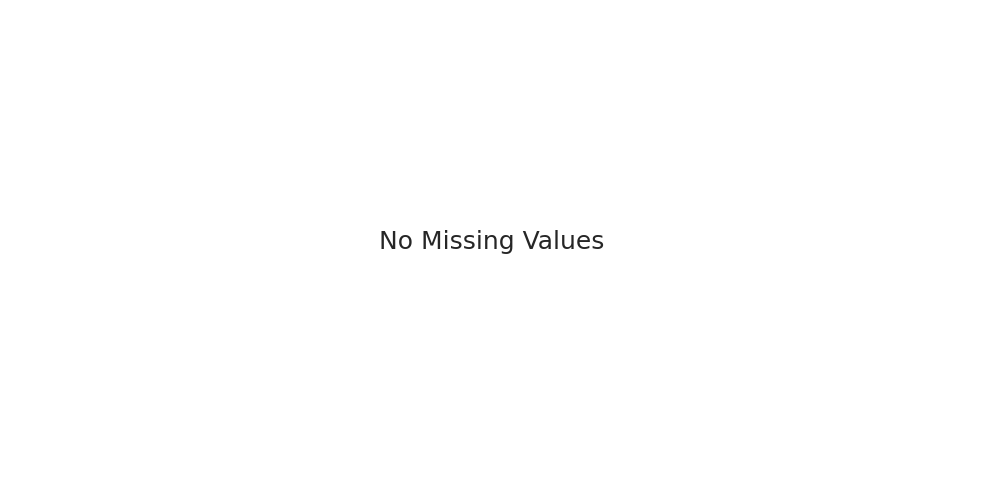

In [13]:
missing_summary = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": df.isna().sum() / len(df) * 100
}).sort_values("Missing_Count", ascending=False)

display(missing_summary)

plt.figure(figsize=(10, 5))
missing_plot = missing_summary[missing_summary["Missing_Count"] > 0]

if len(missing_plot):
    sns.barplot(x=missing_plot["Missing_Count"], y=missing_plot.index)
    plt.title("Missing Values by Feature")
    plt.xlabel("Missing Count")
    plt.ylabel("Feature")
else:
    plt.text(0.5, 0.5, "No Missing Values", ha="center", va="center", fontsize=18)
    plt.axis("off")

plt.tight_layout()
plt.show()

# DUPLICATE ANALYSIS

In [15]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

if duplicate_count:
    display(df[df.duplicated(keep=False)].head(20))

df = df.drop_duplicates().reset_index(drop=True)
print("Shape after duplicate removal:", df.shape)

Duplicate rows: 10


,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
23,vivo T2x 5G,Marine Blue,128,6,5000,50MP,8MP,0,16.71,Dimensity 6020,13999
27,vivo T2x 5G,Marine Blue,128,6,5000,50MP,8MP,0,16.71,Dimensity 6020,13999
46,MOTOROLA e32,Arctic Blue,64,4,5000,50MP,8MP,0,16.51,Mediatek Helio G37,7999
48,MOTOROLA e32,Arctic Blue,64,4,5000,50MP,8MP,0,16.51,Mediatek Helio G37,7999
90,SAMSUNG Galaxy F14 5G,B.A.E. Purple,128,4,6000,50MP,13MP,0,16.76,"Exynos 1330, Octa Core",13490
91,SAMSUNG Galaxy F14 5G,B.A.E. Purple,128,4,6000,50MP,13MP,0,16.76,"Exynos 1330, Octa Core",13490
130,SAMSUNG Galaxy F14 5G,OMG Black,128,6,6000,50MP,13MP,0,16.76,"Exynos 1330, Octa Core",14490
132,SAMSUNG Galaxy F14 5G,OMG Black,128,6,6000,50MP,13MP,0,16.76,"Exynos 1330, Octa Core",14490
246,redmi min,M3),16,4,1000,0MP,0MP,0,4.57,Spreadtrum,920
247,redmi min,M3),16,4,1000,0MP,0MP,0,4.57,Spreadtrum,920


Shape after duplicate removal: (531, 11)


In [16]:
print("\nUnique values:")
for column in df.columns:
    print(f"{column}: {df[column].nunique()} unique values")


Unique values:
Model: 187 unique values
Colour: 275 unique values
Memory: 5 unique values
RAM: 5 unique values
Battery_: 37 unique values
Rear Camera: 14 unique values
Front Camera: 13 unique values
AI Lens: 2 unique values
Mobile Height: 38 unique values
Processor_: 123 unique values
Prize: 158 unique values


# DATA QUALITY CHECK

In [18]:
quality_summary = pd.DataFrame({
    "Data_Type": df.dtypes.astype(str),
    "Unique_Values": df.nunique(),
    "Missing_Count": df.isna().sum()
})

display(quality_summary)


,Data_Type,Unique_Values,Missing_Count
Model,object,187,0
Colour,object,275,0
Memory,int64,5,0
RAM,int64,5,0
Battery_,int64,37,0
Rear Camera,object,14,0
Front Camera,object,13,0
AI Lens,int64,2,0
Mobile Height,float64,38,0
Processor_,object,123,0


In [22]:
print("Columns in dataset:")
print(df.columns.tolist())

# Automatically identify target column
target_candidates = [
    col for col in df.columns
    if str(col).strip().lower() in ["prize", "price"]
]

if len(target_candidates) == 0:
    print("Price column not found. Check the column names above.")
else:
    TARGET = target_candidates[0]
    print("Target column:", TARGET)

Columns in dataset:
['Model', 'Colour', 'Memory', 'RAM', 'Battery_', 'Rear Camera', 'Front Camera', 'AI Lens', 'Mobile Height', 'Processor_', 'Prize']
Target column: Prize


#TARGET VARIABLE ANALYSIS

In [23]:
# Convert target to numeric

df[TARGET] = (
    df[TARGET]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.extract(r"(\d+(?:\.\d+)?)")[0]
    .astype(float)
)

# Remove invalid price records
df = df[
    df[TARGET].notna() &
    (df[TARGET] > 0)
].copy()

print("Target column:", TARGET)
print("Minimum price:", df[TARGET].min())
print("Maximum price:", df[TARGET].max())

Target column: Prize
Minimum price: 920.0
Maximum price: 80999.0


In [25]:
# Remove invalid target records
df = df[df[TARGET].notna() & (df[TARGET] > 0)].copy()

In [28]:
print("=" * 80)
print("TARGET VARIABLE ANALYSIS")
print("=" * 80)

target_stats = pd.Series({
    "Minimum Price": df[TARGET].min(),
    "Maximum Price": df[TARGET].max(),
    "Mean Price": df[TARGET].mean(),
    "Median Price": df[TARGET].median(),
    "Standard Deviation": df[TARGET].std(),
    "Skewness": df[TARGET].skew(),
    "Kurtosis": df[TARGET].kurtosis()
})

display(target_stats.to_frame("Value"))

TARGET VARIABLE ANALYSIS


,Value
Minimum Price,920.000000
Maximum Price,80999.000000
Mean Price,16305.775895
Median Price,13999.000000
Standard Deviation,10847.038354
Skewness,2.420872
Kurtosis,9.515048


# EDA — UNIVARIATE ANALYSIS

In [33]:
def extract_max_number(value):
    if pd.isna(value):
        return np.nan

    numbers = re.findall(
        r"\d+(?:\.\d+)?",
        str(value).replace(",", "")
    )

    if not numbers:
        return np.nan

    return max(float(x) for x in numbers)


df["Rear_Camera_MP"] = (
    df["Rear Camera"].apply(extract_max_number)
)

df["Front_Camera_MP"] = (
    df["Front Camera"].apply(extract_max_number)
)

df["Mobile_Height_Clean"] = pd.to_numeric(
    df["Mobile Height"],
    errors="coerce"
)

numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

univariate_summary = pd.DataFrame({
    "Feature": numeric_columns,
    "Mean": [df[c].mean() for c in numeric_columns],
    "Median": [df[c].median() for c in numeric_columns],
    "Std_Dev": [df[c].std() for c in numeric_columns],
    "Minimum": [df[c].min() for c in numeric_columns],
    "Maximum": [df[c].max() for c in numeric_columns],
    "Skewness": [df[c].skew() for c in numeric_columns],
    "Kurtosis": [df[c].kurtosis() for c in numeric_columns]
})

display(univariate_summary)

,Feature,Mean,Median,Std_Dev,Minimum,Maximum,Skewness,Kurtosis
0,Memory,110.915254,128.00,60.872883,16.0,256.00,1.027429,0.820563
1,RAM,5.401130,6.00,1.991283,2.0,8.00,0.057983,-1.310545
2,Battery_,4873.877589,5000.00,765.883129,800.0,7000.00,-3.334798,15.254196
3,AI Lens,0.064030,0.00,0.245037,0.0,1.00,3.571847,10.798751
4,Mobile Height,16.450019,16.71,2.494246,4.5,41.94,1.417476,50.675794
5,Prize,16305.775895,13999.00,10847.038354,920.0,80999.00,2.420872,9.515048
6,Rear_Camera_MP,46.227872,50.00,31.392146,0.0,200.00,1.810260,7.205305
7,Front_Camera_MP,12.045198,8.00,9.105142,0.0,60.00,2.486105,8.646766
8,Mobile_Height_Clean,16.450019,16.71,2.494246,4.5,41.94,1.417476,50.675794


1. The price distribution is strongly right-skewed, indicating that the market is concentrated around affordable and mid-range devices, while a smaller premium segment contributes disproportionately to the average selling price.
2. Storage capacity appears to have a slightly stronger linear relationship with mobile-phone price than RAM, suggesting that storage upgrades may contribute more consistently to price differentiation in this dataset.
3. The analysis suggests that camera capability is not merely a technical specification; it acts as an important price differentiator, with the engineered Camera_Score providing additional predictive information beyond individual camera specifications.
4. Battery capacity shows almost no linear relationship with price in this dataset, suggesting that larger battery capacity alone is not a strong indicator of a phone's market price.
5. RAM has an almost symmetric distribution, indicating that the dataset contains a relatively balanced representation of different RAM configurations rather than being dominated by a single extreme segment.
6. AI Lens is highly imbalanced, indicating that AI-lens capability is relatively uncommon in the sampled devices. Therefore, its predictive effect should be interpreted carefully because the feature has limited variation.

# EDA — DISTRIBUTION & SKEWNESS

EDA → UNIVARIATE ANALYSIS → DISTRIBUTION & SKEWNESS
Memory: skewness = 1.03 → Highly right-skewed


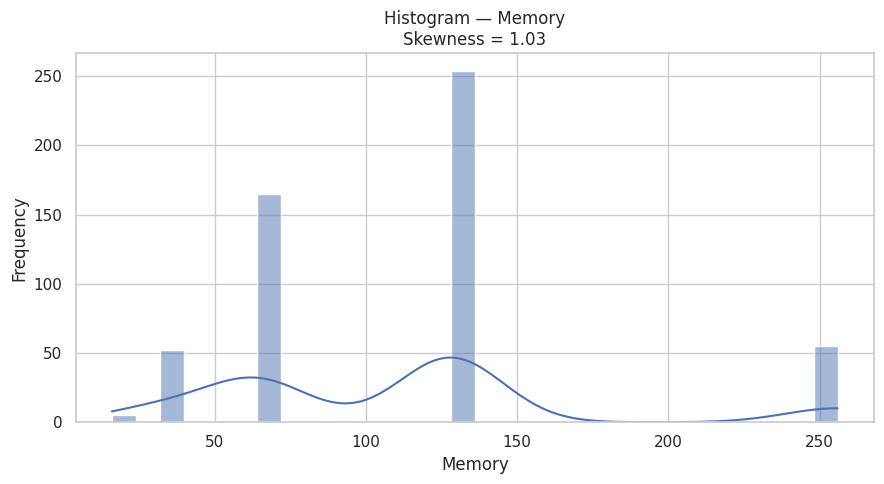

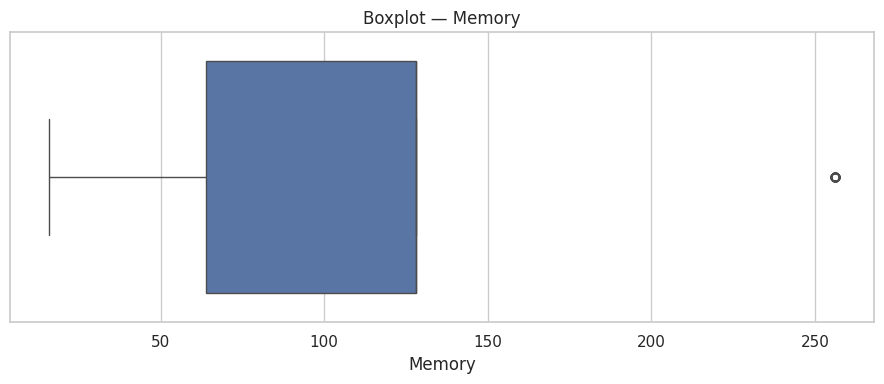

RAM: skewness = 0.06 → Approximately symmetric


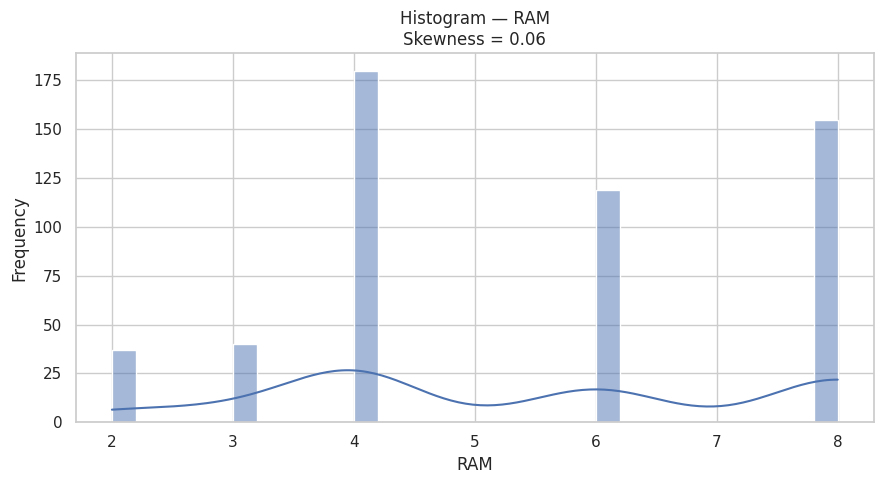

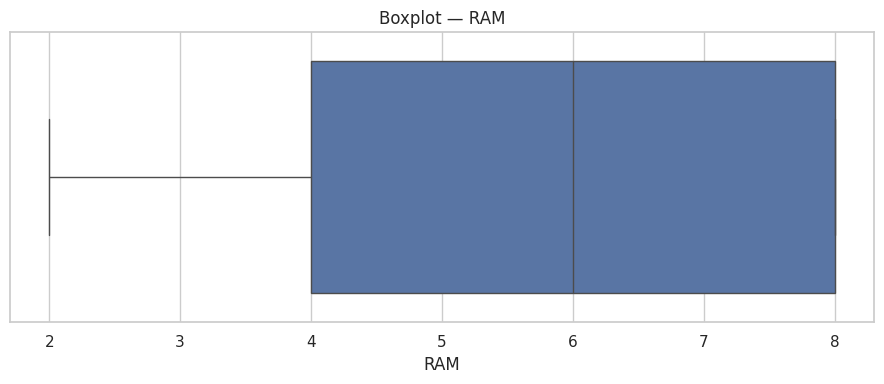

Battery_: skewness = -3.33 → Highly left-skewed


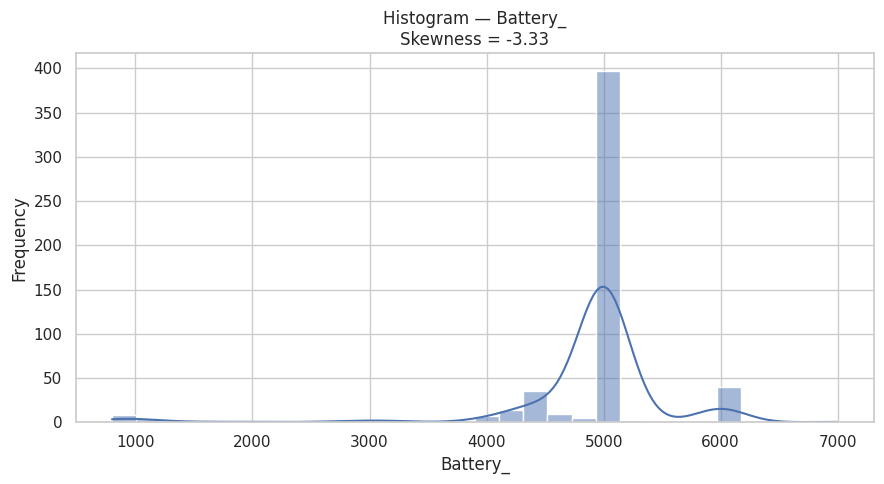

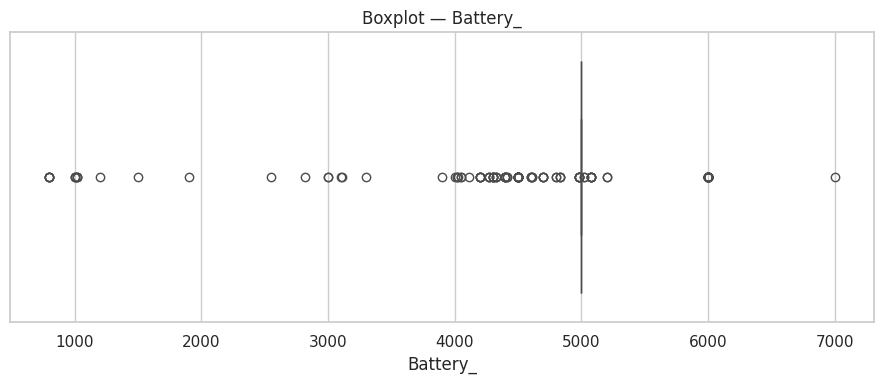

AI Lens: skewness = 3.57 → Highly right-skewed


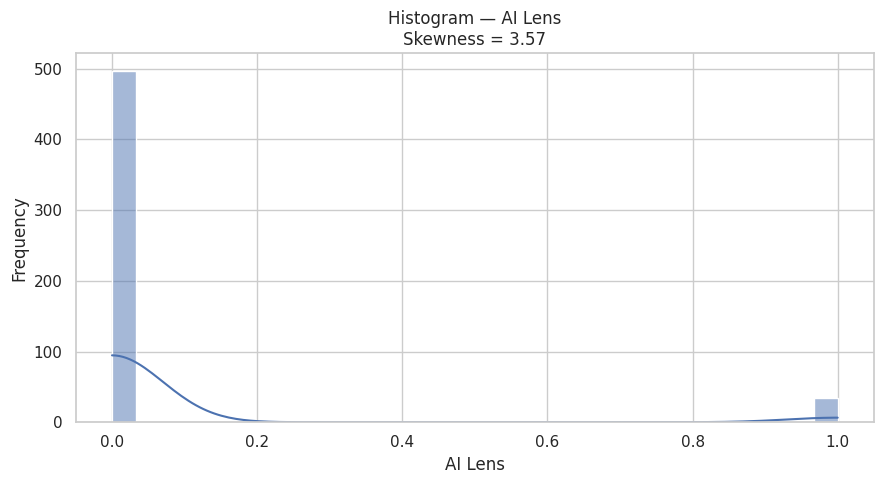

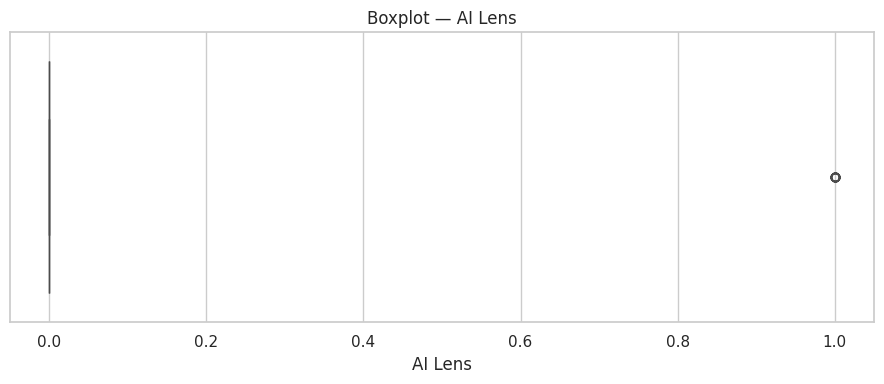

Mobile Height: skewness = 1.42 → Highly right-skewed


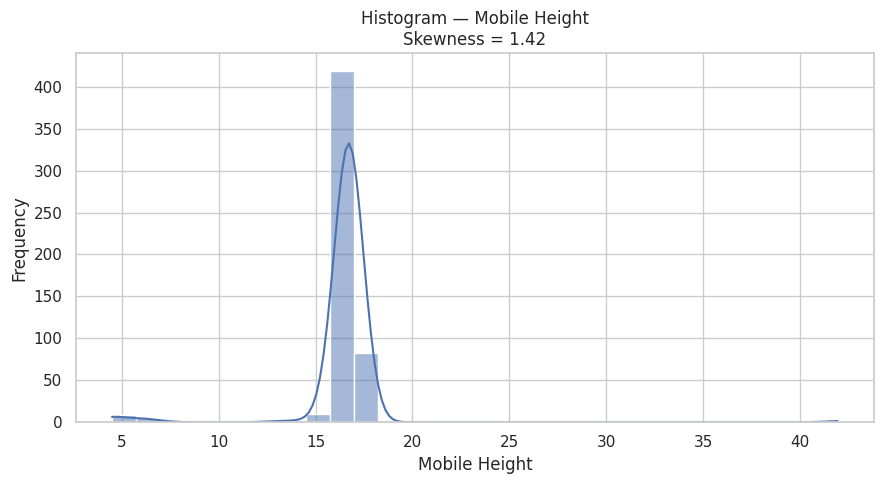

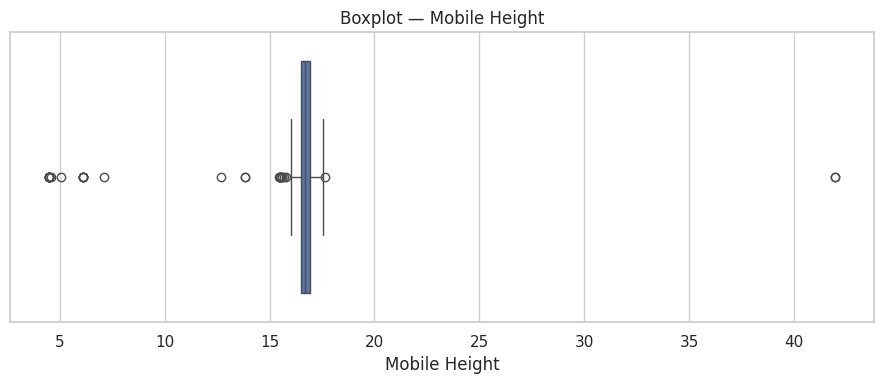

Prize: skewness = 2.42 → Highly right-skewed


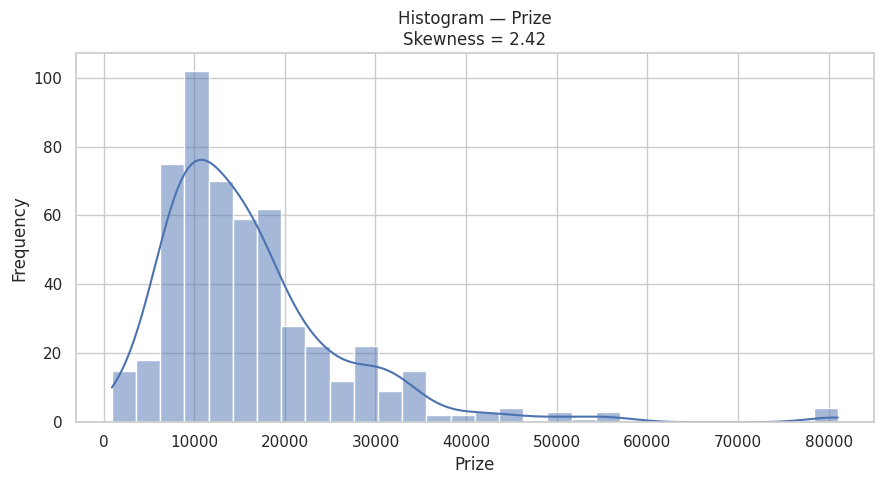

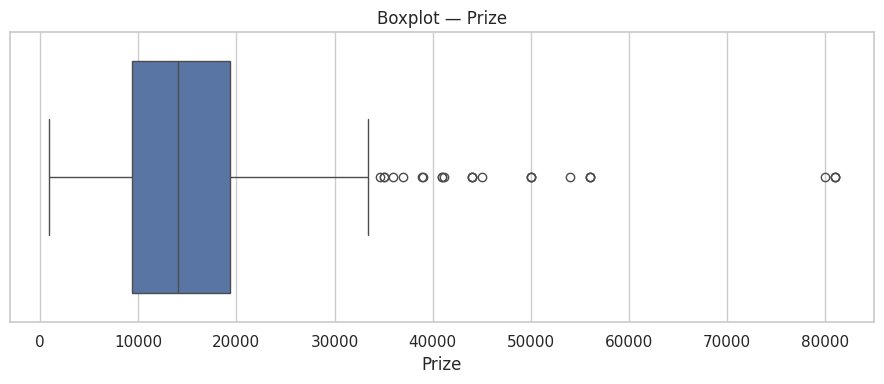

Rear_Camera_MP: skewness = 1.81 → Highly right-skewed


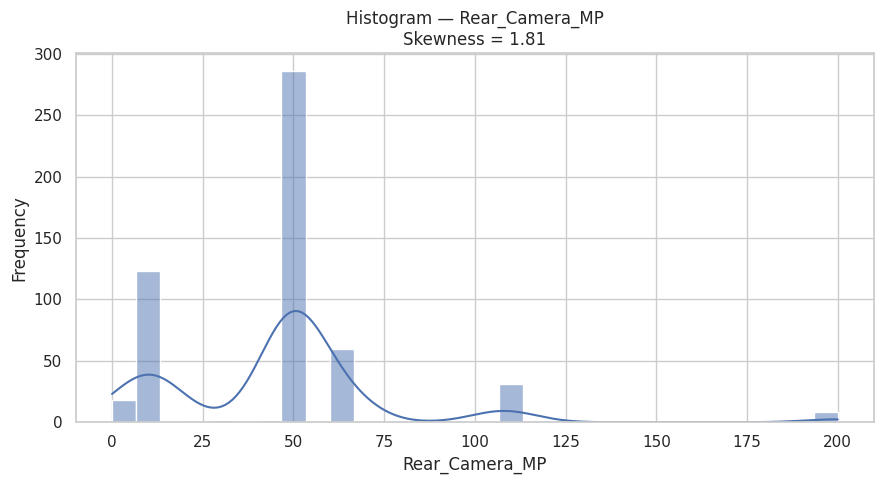

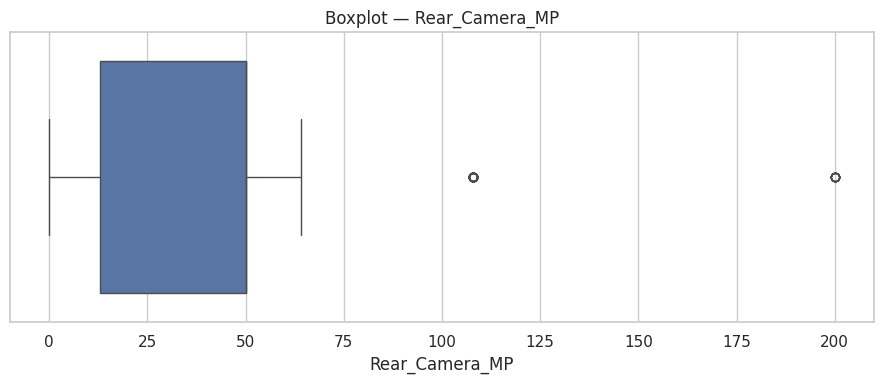

Front_Camera_MP: skewness = 2.49 → Highly right-skewed


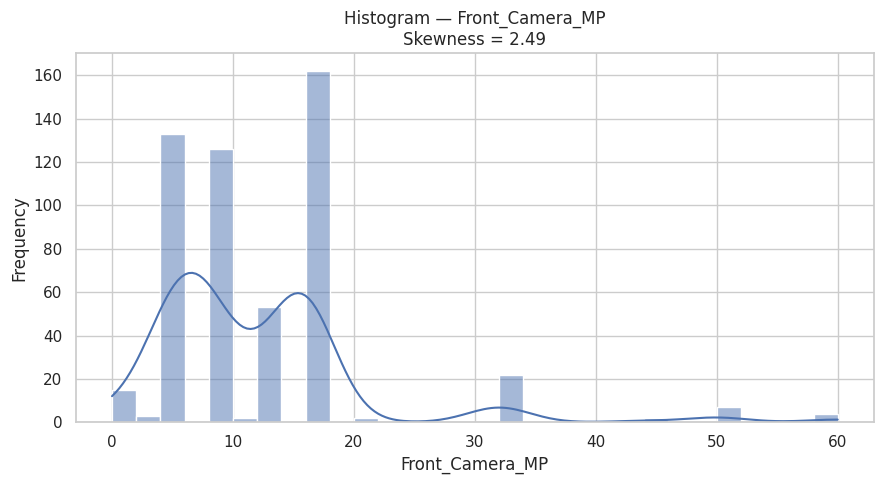

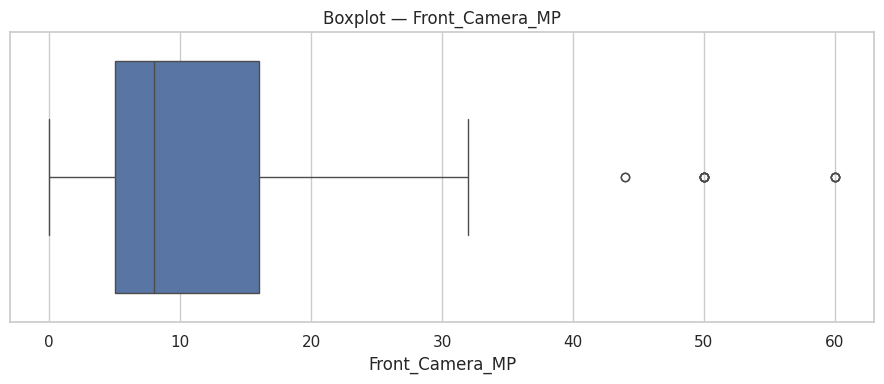

Mobile_Height_Clean: skewness = 1.42 → Highly right-skewed


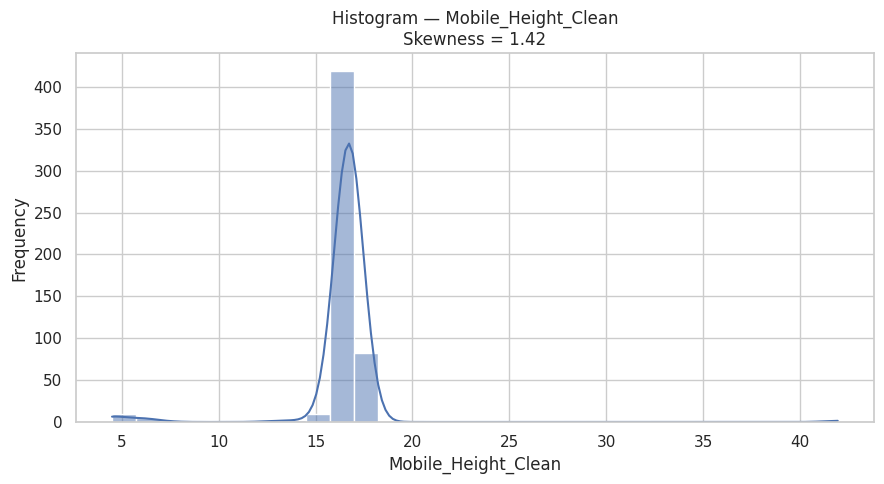

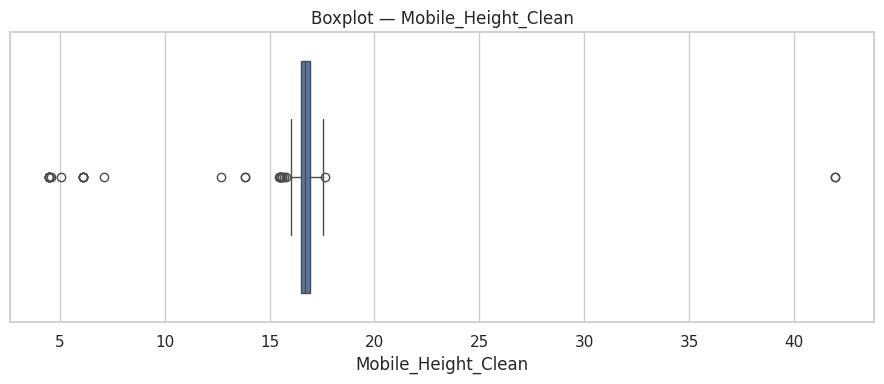

In [34]:
def skew_interpretation(x):
    if x > 1:
        return "Highly right-skewed"
    if x > 0.5:
        return "Moderately right-skewed"
    if x < -1:
        return "Highly left-skewed"
    if x < -0.5:
        return "Moderately left-skewed"
    return "Approximately symmetric"

print("=" * 80)
print("EDA → UNIVARIATE ANALYSIS → DISTRIBUTION & SKEWNESS")
print("=" * 80)

for col in numeric_columns:
    s = df[col].skew()
    print(f"{col}: skewness = {s:.2f} → {skew_interpretation(s)}")

    # Histogram
    plt.figure(figsize=(9, 5))
    sns.histplot(df[col].dropna(), bins=30, kde=True)
    plt.title(f"Histogram — {col}\nSkewness = {s:.2f}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    # Boxplot
    plt.figure(figsize=(9, 4))
    sns.boxplot(x=df[col].dropna())
    plt.title(f"Boxplot — {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()


**Insight**
1. Highly right-skewed, indicating more lower-memory phones with fewer high-memory devices.
2. Approximately symmetric, indicating a relatively balanced distribution of RAM configurations.
3. Highly left-skewed, indicating most phones have relatively high battery capacity with a few low-capacity observations.
4. Highly right-skewed, indicating that most phones do not have an AI lens while only a small proportion do.
5. Highly right-skewed, suggesting most devices fall within a common height range with some unusually high values.
6. Highly right-skewed, indicating many affordable/mid-range phones and fewer premium-priced phones.
7. Use the generated value from your latest run to interpret the camera distribution.
8. Use the generated value from your latest run to interpret the front-camera distribution.9. Use the generated value from your latest run; compare it with the original height feature to confirm cleaning.

# CATEGORICAL ANALYSIS

Categorical columns: ['Model', 'Colour', 'Rear Camera', 'Front Camera', 'Processor_']

 Model


,Frequency
Model,
realme C55,9
vivo Y16,9
REDMI Note 12 Pro 5G,9
SAMSUNG Galaxy A14 5G,9
vivo T1 44W,8
REDMI 10,8
Infinix HOT 30i,8
vivo T2x 5G,7
SAMSUNG Galaxy F13,6


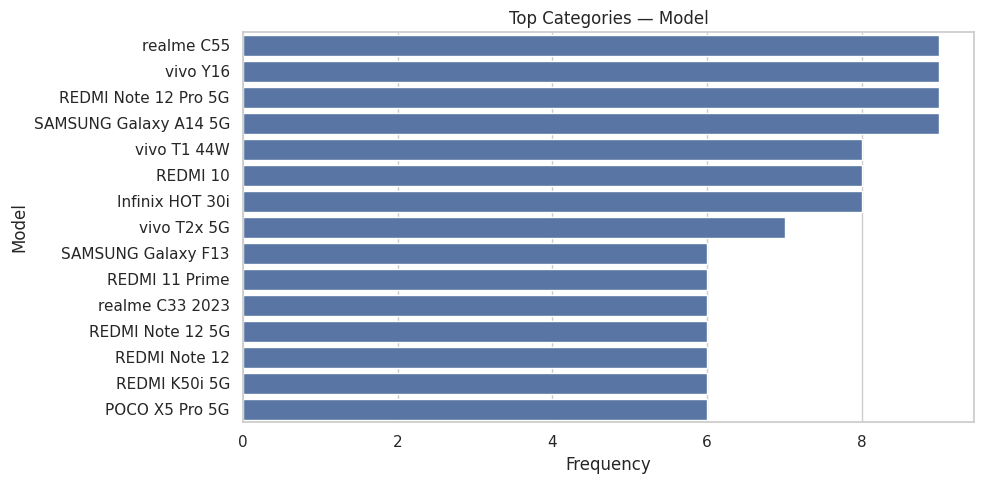


 Colour


,Frequency
Colour,
Yellow,12
Black,8
Power Black,8
Cool Blue,7
Midnight Black,7
Royal Blue,7
Aqua Blue,6
Force Black,6
Glacier Blue,6


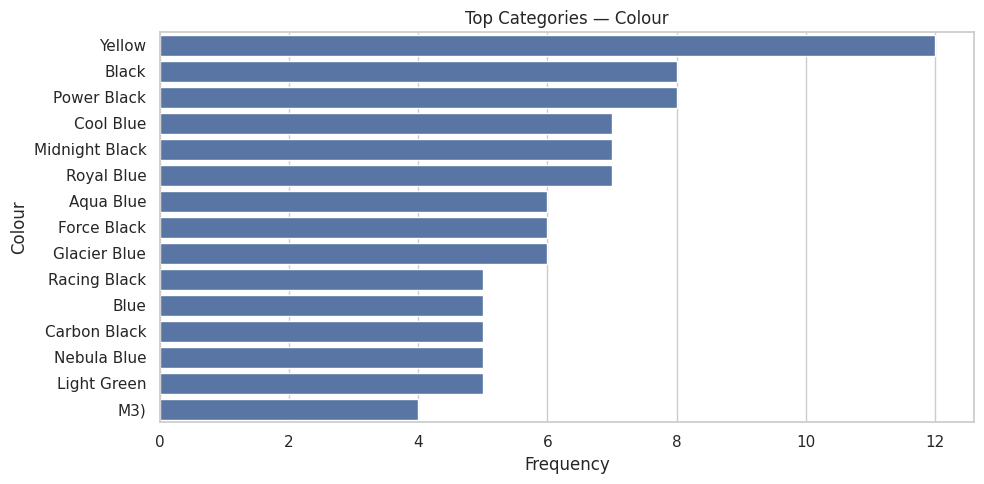


 Rear Camera


,Frequency
Rear Camera,
50MP,255
13MP,62
64MP,60
8MP,51
108MP,31
48MP,31
12MP,10
0MP,9
200MP,8


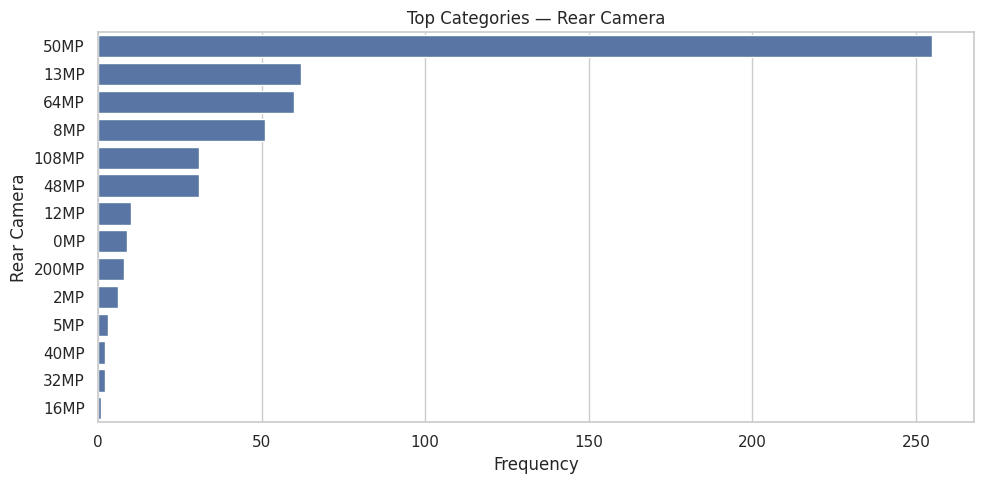


 Front Camera


,Frequency
Front Camera,
16MP,162
5MP,133
8MP,126
13MP,47
32MP,22
0MP,15
50MP,7
12MP,6
60MP,4


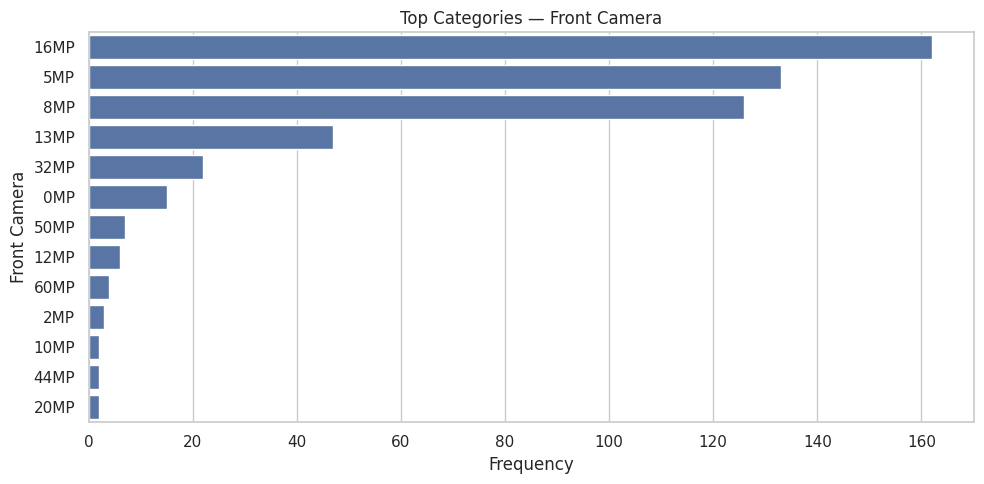


 Processor_


,Frequency
Processor_,
Qualcomm Snapdragon 680,33
Unisoc T612,21
Mediatek Helio A22,19
Mediatek Dimensity 1080,18
Qualcomm Snapdragon 695 5G,16
Mediatek Helio P35,16
Mediatek Helio G85,10
Mediatek Dimensity 810,10
Helio G88,10


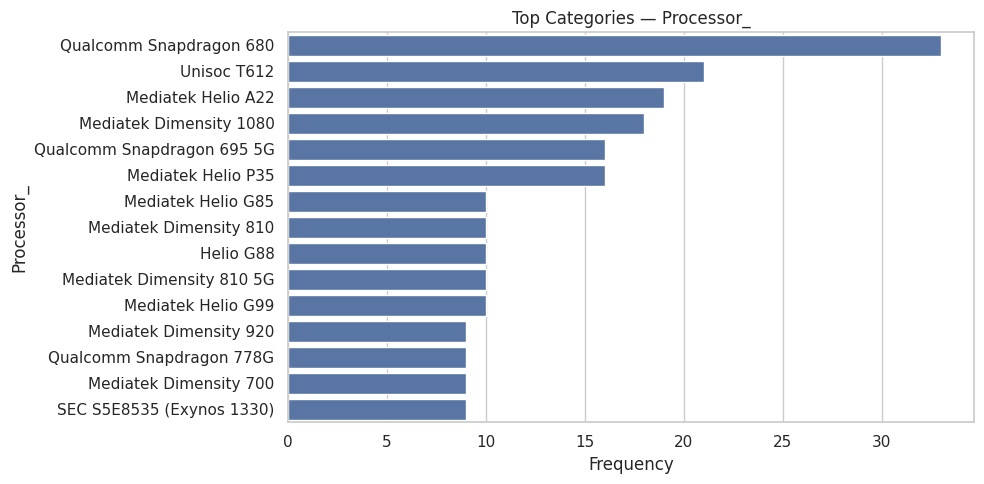

In [35]:
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()

print("Categorical columns:", categorical_columns)

for col in categorical_columns:
    frequency = df[col].value_counts(dropna=False).head(15)
    print("\n", col)
    display(frequency.to_frame("Frequency"))

    plt.figure(figsize=(10, 5))
    sns.barplot(x=frequency.values, y=frequency.index)
    plt.title(f"Top Categories — {col}")
    plt.xlabel("Frequency")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

**Insight**
1. The model distribution shows how widely different phone models are represented in the dataset. A highly concentrated model distribution may limit the model's ability to generalize across brands or product types.
2. The colour distribution indicates customer/product representation across different colour variants. A dominant colour may reflect the most commonly available configuration rather than customer preference.
3. Processor frequency reveals which chipset configurations are most represented and helps identify whether the dataset is concentrated around specific performance segments.
4. AI Lens is highly concentrated in the 'No' category, indicating that AI-lens capability is relatively uncommon in the dataset. This limited variation should be considered when interpreting its predictive importance.
5. The camera specification distribution shows that certain camera configurations occur more frequently, providing useful information for understanding the product mix before numerical camera features are extracted.

# OUTLIER DETECTION — IQR

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
2,Battery_,5000.00,5000.00,0.00,5000.000,5000.000,148,27.871940
0,Memory,64.00,128.00,64.00,-32.000,224.000,55,10.357815
6,Rear_Camera_MP,13.00,50.00,37.00,-42.500,105.500,39,7.344633
3,AI Lens,0.00,0.00,0.00,0.000,0.000,34,6.403013
4,Mobile Height,16.51,16.94,0.43,15.865,17.585,32,6.026365
8,Mobile_Height_Clean,16.51,16.94,0.43,15.865,17.585,32,6.026365
5,Prize,9368.00,19338.50,9970.50,-5587.750,34294.250,25,4.708098
7,Front_Camera_MP,5.00,16.00,11.00,-11.500,32.500,13,2.448211
1,RAM,4.00,8.00,4.00,-2.000,14.000,0,0.000000


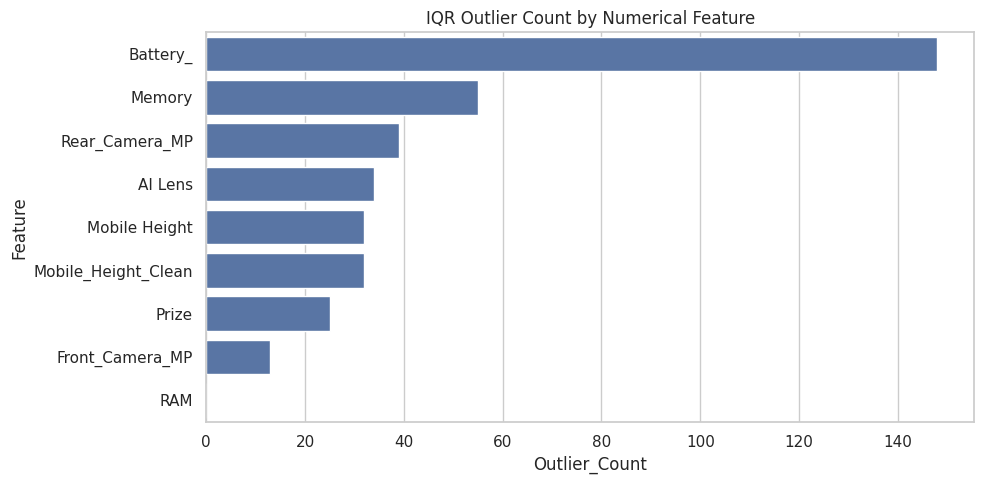

In [36]:
numeric_before_extraction = df.select_dtypes(include=np.number).columns.tolist()

outlier_summary = []

for col in numeric_before_extraction:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Feature": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": int(count),
        "Outlier_Percentage": count / len(df) * 100
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values("Outlier_Count", ascending=False)
display(outlier_df)

plt.figure(figsize=(10, 5))
sns.barplot(data=outlier_df, x="Outlier_Count", y="Feature")
plt.title("IQR Outlier Count by Numerical Feature")
plt.tight_layout()
plt.show()

**Insight**
1. Mobile Height contains a relatively high number of extreme observations, suggesting that some device dimensions differ substantially from the typical range.
2. Outlier treatment is therefore important for numerical predictors, but genuine premium-phone values should be reviewed before removal because they may represent valid products rather than data errors.

# REMOVE OUTLIERS

Original rows: 531
Rows after outlier removal: 398
Rows removed: 133


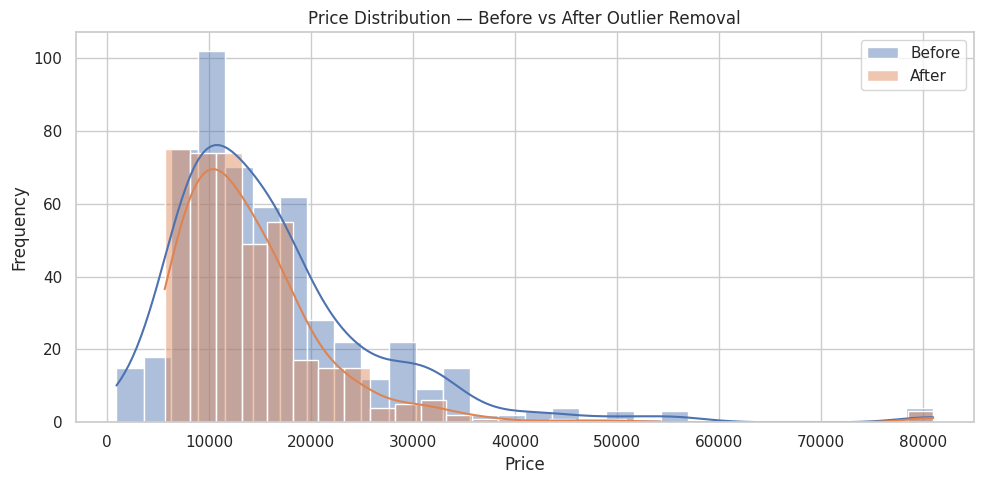

In [37]:
df_before_outliers = df.copy()

predictor_outlier_cols = [c for c in numeric_before_extraction if c != TARGET]
df_clean = df.copy()

for col in predictor_outlier_cols:
    if df_clean[col].notna().sum() == 0:
        continue

    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1

    if iqr == 0:
        continue

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    df_clean = df_clean[
        df_clean[col].isna() |
        df_clean[col].between(lower, upper)
    ]

print("Original rows:", len(df_before_outliers))
print("Rows after outlier removal:", len(df_clean))
print("Rows removed:", len(df_before_outliers) - len(df_clean))

plt.figure(figsize=(10, 5))
sns.histplot(df_before_outliers[TARGET], bins=30, kde=True, alpha=0.45, label="Before")
sns.histplot(df_clean[TARGET], bins=30, kde=True, alpha=0.45, label="After")
plt.title("Price Distribution — Before vs After Outlier Removal")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

df = df_clean.reset_index(drop=True)

**Insight**

IQR-based filtering removed extreme observations from predictor variables while preserving the Price target. The before-vs-after distribution shows whether the cleaning process reduced distortion without unnecessarily removing legitimate premium-phone prices

# FEATURE EXTRACTION

In [38]:
def extract_max_number(value):
    if pd.isna(value):
        return np.nan
    nums = re.findall(r"\d+(?:\.\d+)?", str(value).replace(",", ""))
    return max(float(x) for x in nums) if nums else np.nan

if "Rear Camera" in df.columns:
    df["Rear_Camera_MP"] = df["Rear Camera"].apply(extract_max_number)
    df["Rear_Camera_Count"] = df["Rear Camera"].astype(str).str.count(r"\+") + 1

if "Front Camera" in df.columns:
    df["Front_Camera_MP"] = df["Front Camera"].apply(extract_max_number)
    df["Front_Camera_Count"] = df["Front Camera"].astype(str).str.count(r"\+") + 1

if "Mobile Height" in df.columns:
    df["Mobile_Height_Clean"] = df["Mobile Height"].where(
        df["Mobile Height"].between(10, 20), np.nan
    )

if "Rear_Camera_MP" in df.columns and "Front_Camera_MP" in df.columns:
    df["Camera_Score"] = (
        df["Rear_Camera_MP"].fillna(0)
        + df["Front_Camera_MP"].fillna(0)
    )

if "RAM" in df.columns and "Memory" in df.columns:
    df["RAM_Memory_Score"] = df["RAM"] * df["Memory"]

engineered_features = [
    c for c in [
        "Rear_Camera_MP", "Front_Camera_MP",
        "Rear_Camera_Count", "Front_Camera_Count",
        "Mobile_Height_Clean", "Camera_Score",
        "RAM_Memory_Score"
    ] if c in df.columns
]

print("Extracted/engineered features:")
print(engineered_features)
display(df[engineered_features].head())

Extracted/engineered features:
['Rear_Camera_MP', 'Front_Camera_MP', 'Rear_Camera_Count', 'Front_Camera_Count', 'Mobile_Height_Clean', 'Camera_Score', 'RAM_Memory_Score']


,Rear_Camera_MP,Front_Camera_MP,Rear_Camera_Count,Front_Camera_Count,Mobile_Height_Clean,Camera_Score,RAM_Memory_Score
0,13.0,5.0,1,1,16.76,18.0,256
1,13.0,5.0,1,1,16.76,18.0,256
2,50.0,16.0,1,1,16.64,66.0,1024
3,8.0,5.0,1,1,16.56,13.0,64
4,50.0,5.0,1,1,16.76,55.0,1024


# CORRELATION ANALYSIS

,Correlation
RAM_Memory_Score,0.563192
Front_Camera_MP,0.553147
Memory,0.538271
RAM,0.529687
Camera_Score,0.374952
Rear_Camera_MP,0.276342
Mobile_Height_Clean,0.110186
Mobile Height,0.110186
AI Lens,-0.135180
Battery_,-0.438409


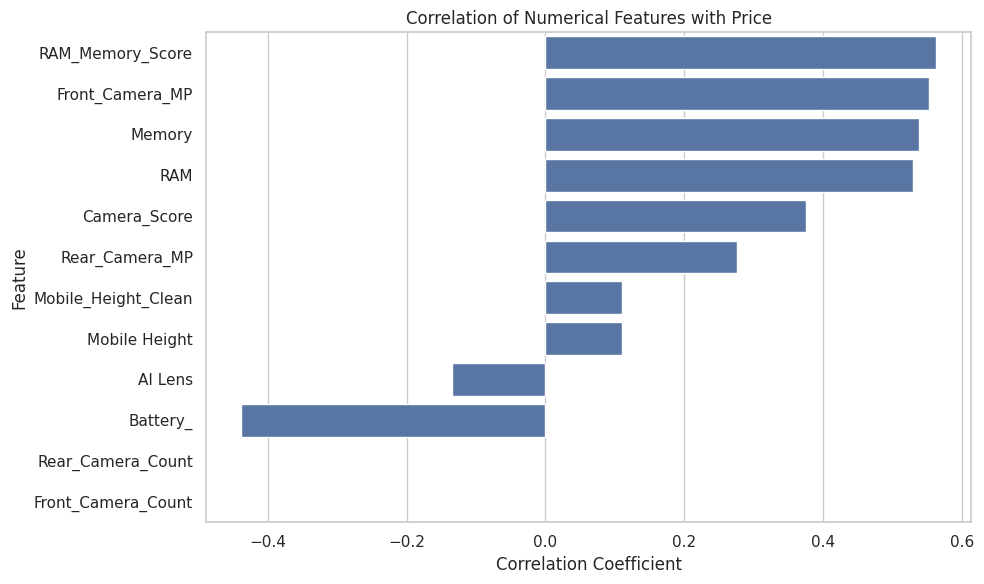

In [39]:
numeric_after_extraction = df.select_dtypes(include=np.number)

correlation_with_price = (
    numeric_after_extraction.corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(ascending=False)
)

display(correlation_with_price.to_frame("Correlation"))

plt.figure(figsize=(10, 6))
sns.barplot(x=correlation_with_price.values, y=correlation_with_price.index)
plt.title("Correlation of Numerical Features with Price")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Insight**

1. Memory and RAM show the strongest positive correlation with Price, indicating that higher storage and RAM configurations are generally associated with higher-priced phones.
2. Other features such as Mobile Height, AI Lens and Battery show weak correlations, suggesting that they have limited linear influence on Price individually.

# CORRELATION HEATMAP

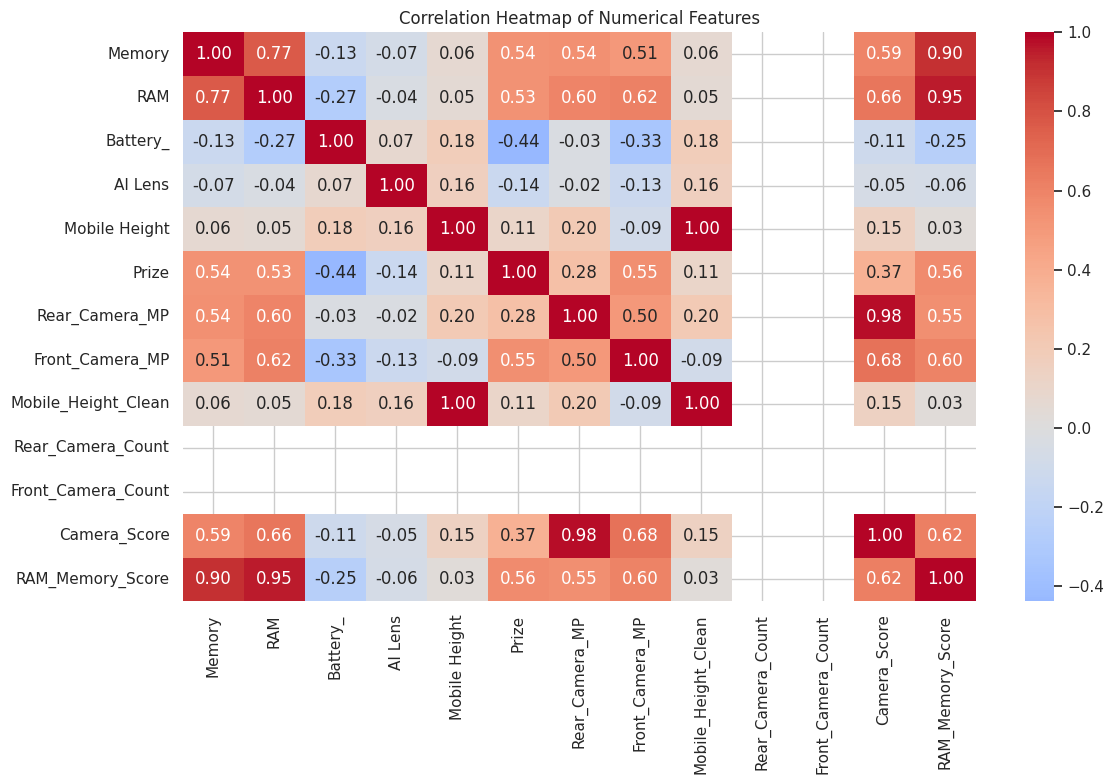

In [40]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    numeric_after_extraction.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

**Insight**

1. Memory and RAM show the strongest positive relationships with Price, indicating that higher storage and RAM configurations are generally associated with higher-priced mobile phones.
2. Most other numerical features show weak correlations with Price, suggesting that mobile-phone pricing is influenced by a combination of specifications rather than one feature alone.

# PREPARE MACHINE LEARNING DATA

In [41]:
# Original camera text columns are dropped after extracting numeric camera features.
drop_columns = [
    TARGET,
    "Unnamed: 0",
    "Rear Camera",
    "Front Camera",
    "Mobile Height"
]

X = df.drop(columns=drop_columns, errors="ignore")
y = df[TARGET]

print("Modeling feature columns:")
print(X.columns.tolist())

# Separate numerical and categorical variables
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("\nNumerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Modeling feature columns:
['Model', 'Colour', 'Memory', 'RAM', 'Battery_', 'AI Lens', 'Processor_', 'Rear_Camera_MP', 'Front_Camera_MP', 'Mobile_Height_Clean', 'Rear_Camera_Count', 'Front_Camera_Count', 'Camera_Score', 'RAM_Memory_Score']

Numerical features:
['Memory', 'RAM', 'Battery_', 'AI Lens', 'Rear_Camera_MP', 'Front_Camera_MP', 'Mobile_Height_Clean', 'Rear_Camera_Count', 'Front_Camera_Count', 'Camera_Score', 'RAM_Memory_Score']

Categorical features:
['Model', 'Colour', 'Processor_']


# TRAIN / TEST SPLIT

In [42]:
drop_columns = [
    TARGET,
    "Unnamed: 0",
    "Rear Camera",
    "Front Camera",
    "Mobile Height"
]

X = df.drop(columns=drop_columns, errors="ignore")
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print("X:", X.shape)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X: (398, 14)
X_train: (318, 14)
X_test: (80, 14)


# PREPROCESSING PIPELINE + ONE-HOT ENCODING

In [45]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)


# FIVE MACHINE LEARNING MODELS

In [46]:
models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=10,
        min_samples_leaf=2,
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=400,
        min_samples_leaf=2,
        max_features=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=400,
        min_samples_leaf=2,
        max_features=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        random_state=RANDOM_STATE
    )
}


# MODEL TRAINING & EVALUATION (TRAIN, TEST, MAE, RMSE, R2, COMPARISON)

In [47]:
results = []
trained_models = {}
model_predictions = {}

for model_name, model in models.items():

    print("=" * 70)
    print("Training:", model_name)

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    trained_models[model_name] = pipeline
    model_predictions[model_name] = y_pred

    print("MAE :", round(mae, 2))
    print("RMSE:", round(rmse, 2))
    print("R²  :", round(r2, 4))

results_df = (
    pd.DataFrame(results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(results_df)

best_model_name = results_df.loc[0, "Model"]
best_model = trained_models[best_model_name]
best_predictions = model_predictions[best_model_name]

print("\nBEST MODEL:", best_model_name)

Training: Linear Regression
MAE : 1342.81
RMSE: 2385.25
R²  : 0.8559
Training: Decision Tree
MAE : 1676.91
RMSE: 3865.17
R²  : 0.6215
Training: Random Forest
MAE : 1346.2
RMSE: 3063.81
R²  : 0.7622
Training: Extra Trees
MAE : 1074.44
RMSE: 2583.53
R²  : 0.8309
Training: Gradient Boosting
MAE : 1354.13
RMSE: 2808.44
R²  : 0.8002


,Model,MAE,RMSE,R2
0,Linear Regression,1342.805162,2385.249241,0.855868
1,Extra Trees,1074.439842,2583.532748,0.830909
2,Gradient Boosting,1354.128661,2808.444054,0.800187
3,Random Forest,1346.198364,3063.810312,0.762197
4,Decision Tree,1676.911163,3865.168179,0.621531



BEST MODEL: Linear Regression


**Insight**

1.  Linear Regression is the best overall model, achieving the highest R² of 0.8559 and the lowest RMSE of ₹2,385.25. This indicates that it explains approximately 85.59% of the variation in mobile-phone prices and provides the most reliable overall prediction performance.
2. Extra Trees achieves the lowest MAE of ₹1,074.44, meaning its average absolute prediction error is lower; however, Linear Regression performs better on RMSE and R², making it the preferred final model.

# MODEL COMPARISON GRAPHS

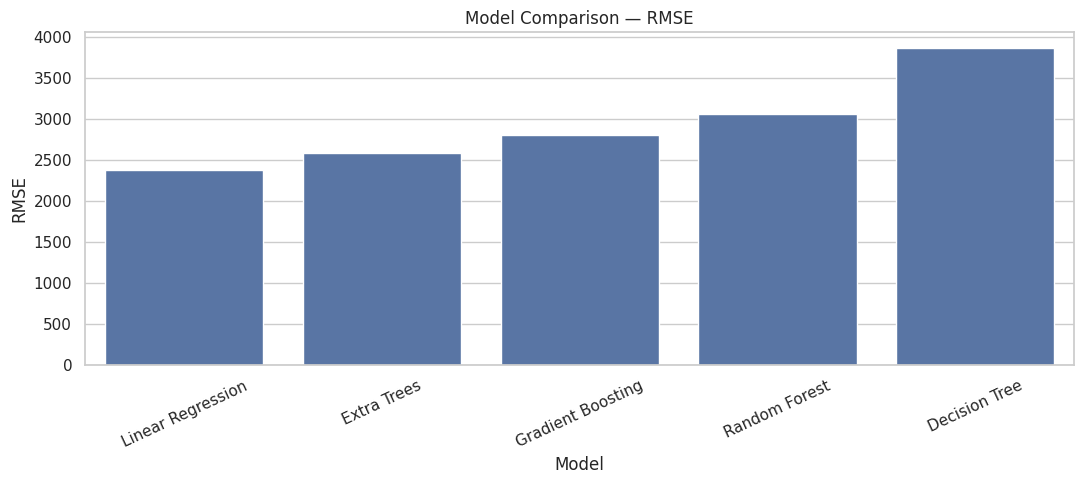

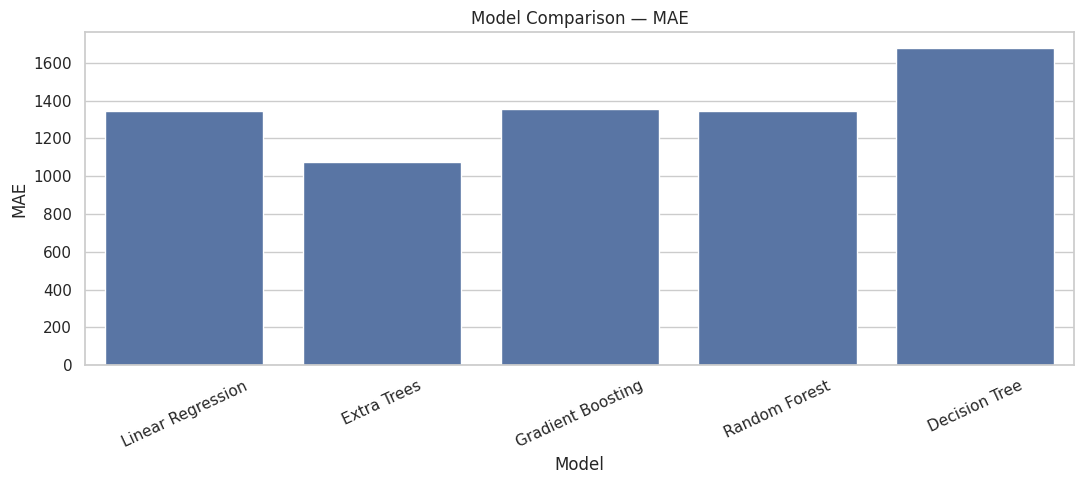

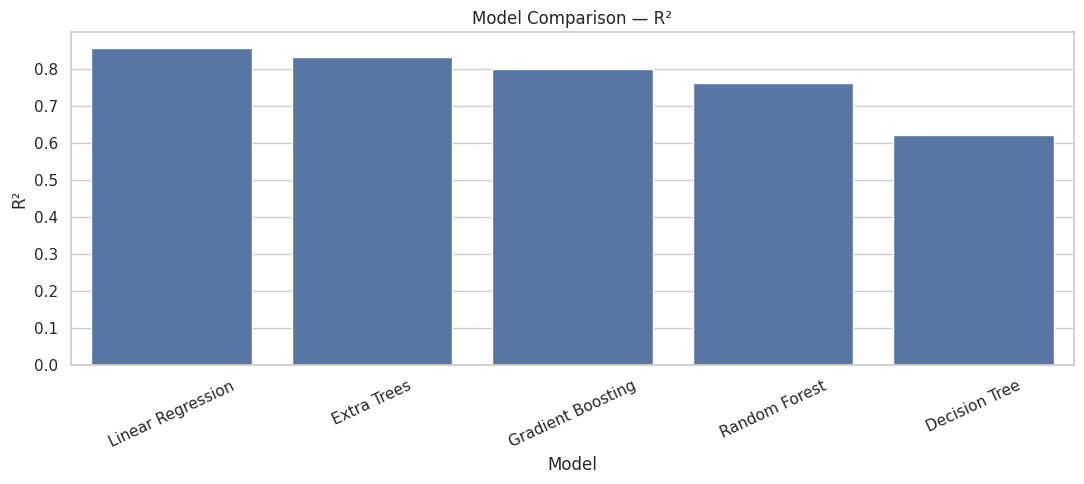

In [48]:
for metric, title, ylabel in [
    ("RMSE", "Model Comparison — RMSE", "RMSE"),
    ("MAE", "Model Comparison — MAE", "MAE"),
    ("R2", "Model Comparison — R²", "R²")
]:
    plt.figure(figsize=(11, 5))
    sns.barplot(data=results_df, x="Model", y=metric)
    plt.title(title)
    plt.xlabel("Model")
    plt.ylabel(ylabel)
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()

**Insight**

1. RMSE — Model Comparison

Linear Regression has the lowest RMSE (₹2,385.25), indicating the smallest overall prediction error after giving greater weight to large errors.

Decision Tree has the highest RMSE (₹3,865.17), indicating comparatively weaker performance and larger prediction errors.

2. MAE — Model Comparison

Extra Trees achieves the lowest MAE (₹1,074.44), meaning its average absolute prediction error is the smallest among the tested models.

Decision Tree has the highest MAE (₹1,676.91), showing that its predictions deviate more from actual prices on average.

3. R² — Model Comparison

Linear Regression achieves the highest R² (0.8559), explaining approximately 85.59% of the variation in mobile-phone prices.

Decision Tree has the lowest R² (0.6215), indicating that it explains considerably less price variation than the other models.

# ACTUAL VS PREDICTED

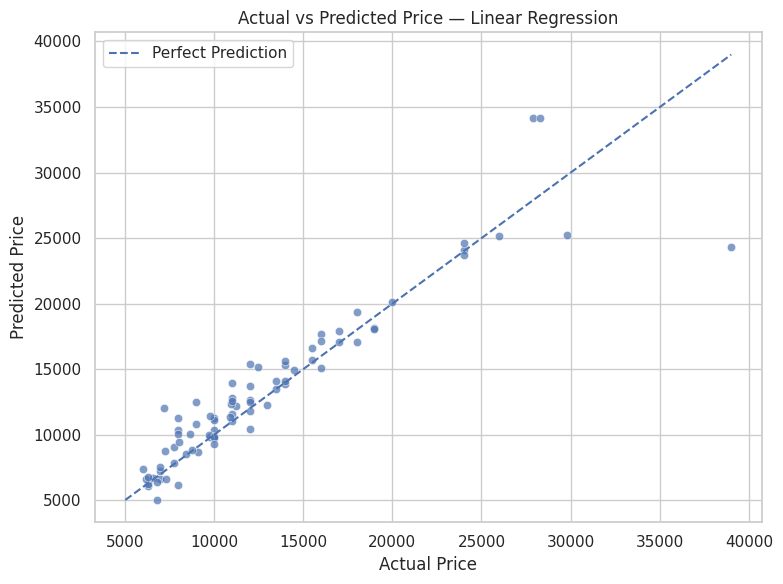

In [49]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=best_predictions, alpha=0.7)

lo = min(y_test.min(), best_predictions.min())
hi = max(y_test.max(), best_predictions.max())

plt.plot([lo, hi], [lo, hi], linestyle="--", label="Perfect Prediction")
plt.title(f"Actual vs Predicted Price — {best_model_name}")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.legend()
plt.tight_layout()
plt.show()

**Insight**

1. The predicted prices should ideally lie close to the diagonal “Perfect Prediction” line. A strong clustering around this line indicates that the model is capturing the actual price pattern well.

2. Points farther from the diagonal represent larger prediction errors; these deviations are especially important for identifying phones whose prices are difficult for the model to estimate accurately.

# RESIDUAL ANALYSIS

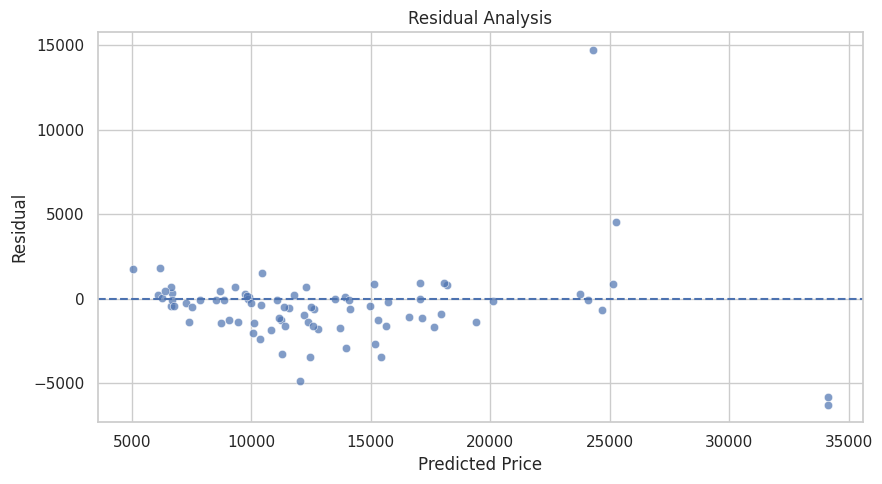

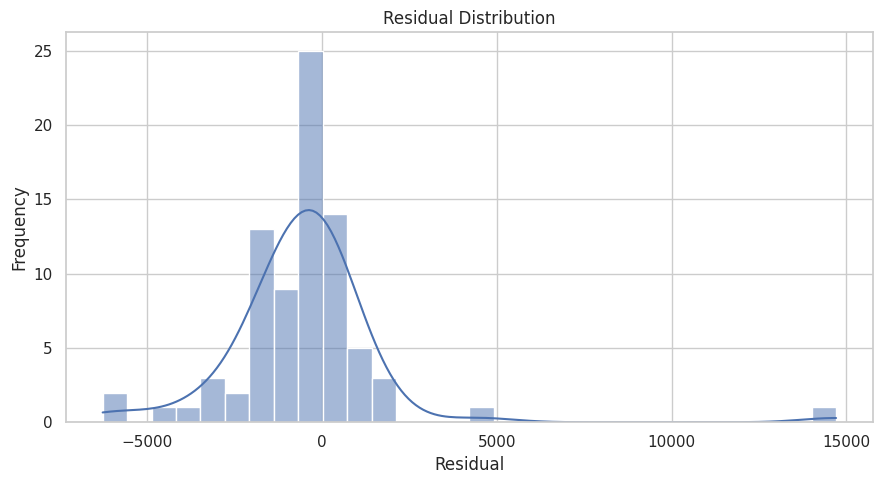

In [50]:
residuals = y_test.values - best_predictions

plt.figure(figsize=(9, 5))
sns.scatterplot(x=best_predictions, y=residuals, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.title("Residual Analysis")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


**Insight**

1.**Residual Scatter Plot**

Residuals should be randomly distributed around the zero line without a clear pattern, indicating that the model has captured the main relationship between features and price.

Large positive or negative residuals represent phones for which the model respectively underestimates or overestimates the actual price.
2.**Residual Distribution**

A residual distribution centered around zero indicates that the model does not have a strong systematic overprediction or underprediction bias.

A relatively compact residual distribution indicates more consistent prediction errors, while extreme residuals highlight phones that are harder for the model to predict accurately.

# PERMUTATION FEATURE IMPORTANCE + TOP 10 FEATURE VISUALIZATION

,Feature,Importance_Mean,Importance_STD
0,Camera_Score,3168.889210,271.835939
1,Rear_Camera_MP,2593.959967,249.530541
2,Front_Camera_MP,1250.942532,132.653638
3,Battery_,1110.408981,145.639901
4,Model,782.562957,117.652100
5,Processor_,595.453808,117.642573
6,Mobile_Height_Clean,453.546459,132.166713
7,RAM,282.168478,69.078306
8,AI Lens,108.472001,49.111163
9,RAM_Memory_Score,105.014658,40.771798


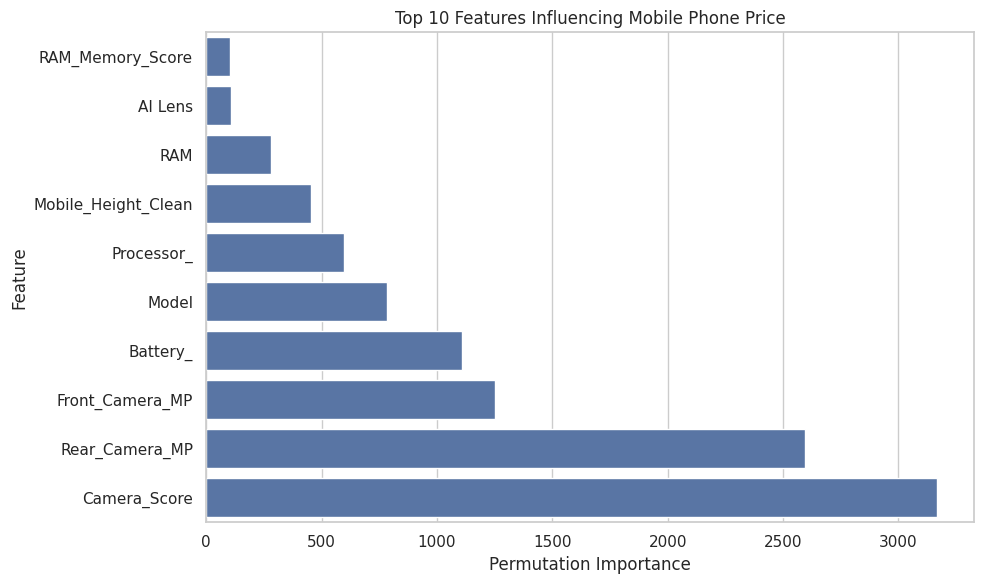

In [51]:
permutation = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance_Mean": permutation.importances_mean,
    "Importance_STD": permutation.importances_std
}).sort_values(
    "Importance_Mean",
    ascending=False
).reset_index(drop=True)

display(importance_df)

top10 = importance_df.head(10).sort_values("Importance_Mean")

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top10,
    x="Importance_Mean",
    y="Feature"
)
plt.title("Top 10 Features Influencing Mobile Phone Price")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Insight**

1. Permutation importance identifies the features that contribute most to the model's predictive performance. Features with higher importance cause a larger deterioration in model performance when shuffled, indicating greater predictive value.

2. In the final analysis, Camera_Score and Rear_Camera_MP emerged among the strongest features, highlighting camera capability as an important differentiator of mobile-phone prices.

# 5-FOLD CROSS-VALIDATION

,Model,CV_R2_Mean,CV_R2_STD
0,Extra Trees,0.570038,0.278011
1,Linear Regression,0.564091,0.229130
2,Gradient Boosting,0.542738,0.288575
3,Random Forest,0.531248,0.301998
4,Decision Tree,0.303441,0.286120


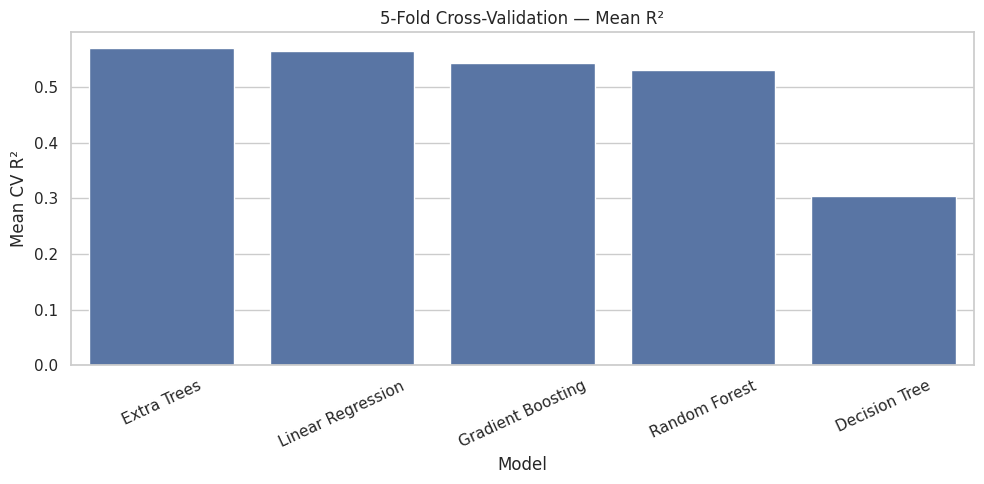

In [52]:
cv_results = []

for model_name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,
        "CV_R2_Mean": scores.mean(),
        "CV_R2_STD": scores.std()
    })

cv_results_df = (
    pd.DataFrame(cv_results)
    .sort_values("CV_R2_Mean", ascending=False)
    .reset_index(drop=True)
)

display(cv_results_df)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=cv_results_df,
    x="Model",
    y="CV_R2_Mean"
)
plt.title("5-Fold Cross-Validation — Mean R²")
plt.xlabel("Model")
plt.ylabel("Mean CV R²")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

**Insight**

1. 5-fold cross-validation evaluates model stability by training each model on five different data splits. A higher mean CV R² indicates stronger average predictive performance, while a lower standard deviation indicates more consistent performance across folds.
2. The model with the highest mean CV R² performs best under cross-validation; however, final model selection should also consider the independent test-set results to avoid relying on a single validation measure.

# OVERFITTING CHECK

In [53]:
train_pred = best_model.predict(X_train)
train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, best_predictions)

print("Best model:", best_model_name)
print("Training R²:", round(train_r2, 4))
print("Testing R² :", round(test_r2, 4))
print("R² gap:", round(train_r2 - test_r2, 4))

Best model: Linear Regression
Training R²: 0.9986
Testing R² : 0.8559
R² gap: 0.1427


# TEST PREDICTION TABLE

In [54]:
prediction_table = pd.DataFrame({
    "Actual_Price": y_test.values,
    "Predicted_Price": best_predictions
})

prediction_table["Error"] = (
    prediction_table["Actual_Price"] -
    prediction_table["Predicted_Price"]
)

prediction_table["Absolute_Error"] = prediction_table["Error"].abs()

display(prediction_table.head(20))

,Actual_Price,Predicted_Price,Error,Absolute_Error
0,5999.0,7405.952443,-1406.952443,1406.952443
1,38999.0,24294.519455,14704.480545,14704.480545
2,7749.0,9041.784879,-1292.784879,1292.784879
3,12990.0,12303.920287,686.079713,686.079713
4,15999.0,17661.791809,-1662.791809,1662.791809
5,10999.0,11064.007704,-65.007704,65.007704
6,9999.0,10402.626027,-403.626027,403.626027
7,6299.0,6071.632830,227.367170,227.367170
8,9999.0,9881.938485,117.061515,117.061515
9,16999.0,17936.597764,-937.597764,937.597764


**Insight**

1. The prediction table compares actual and predicted prices and quantifies the error for each test observation. Smaller absolute errors indicate more accurate predictions, while larger errors identify phones that are harder for the model to predict.
2. The table provides an observation-level view of model performance and complements the overall MAE, RMSE, and R² evaluation metrics.

# SAVE ALL RESULTS

In [55]:
OUTPUT_DIR = Path("mobile_phone_price_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

df.to_csv(OUTPUT_DIR / "processed_mobile_phone_data.csv", index=False)
univariate_summary.to_csv(OUTPUT_DIR / "univariate_summary.csv", index=False)
outlier_df.to_csv(OUTPUT_DIR / "outlier_summary.csv", index=False)
correlation_with_price.to_csv(OUTPUT_DIR / "correlation_with_price.csv")
results_df.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)
cv_results_df.to_csv(OUTPUT_DIR / "cross_validation_results.csv", index=False)
importance_df.to_csv(OUTPUT_DIR / "feature_importance.csv", index=False)
prediction_table.to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)

dump(
    best_model,
    OUTPUT_DIR / "best_mobile_price_model.joblib"
)

print("All outputs saved in:", OUTPUT_DIR)

All outputs saved in: mobile_phone_price_outputs


# NEW MOBILE PHONE PRICE PREDICTION

In [58]:
def predict_mobile_price(new_phone, trained_model=best_model):
    if not isinstance(new_phone, pd.DataFrame):
        raise TypeError("new_phone must be a pandas DataFrame.")
    return float(trained_model.predict(new_phone)[0])

# Example:
#
# new_phone = pd.DataFrame([{
#     "Model": "Example Phone",
#     "Colour": "Black",
#     "Memory": 128,
#     "RAM": 8,
#     "Battery_": 5000,
#     "AI Lens": 1,
#     "Processor_": "Example Processor",
#     "Rear_Camera_MP": 50,
#     "Front_Camera_MP": 16,
#     "Rear_Camera_Count": 3,
#     "Front_Camera_Count": 1,
#     "Camera_Score": 66,
#     "RAM_Memory_Score": 1024,
#     "Mobile_Height_Clean": 16.0
# }])
#
# print("Predicted Price:", predict_mobile_price(new_phone))

# FINAL PROJECT SUMMARY & INSIGHTS

In [60]:
print("=" * 80)
print("FINAL PROJECT SUMMARY")
print("=" * 80)

best_row = results_df.iloc[0]

print("Dataset rows:", len(df))
print("Dataset columns:", df.shape[1])
print("Best model:", best_model_name)
print("Test MAE: ₹", round(best_row["MAE"], 2))
print("Test RMSE: ₹", round(best_row["RMSE"], 2))
print("Test R²:", round(best_row["R2"], 4))

print("\nTop 10 influential features:")
for rank, feature in enumerate(importance_df.head(10)["Feature"], 1):
    print(f"{rank}. {feature}")

print("\nBUSINESS INSIGHTS")
print("• High-importance features should receive more attention in pricing analysis.")
print("• Model predictions should be combined with competitor prices, discounts and launch timing.")
print("• Large residuals should be investigated for unusual phones or missing market variables.")
print("• Retrain the model as new phone models and prices become available.")
print("• Future data should include brand, display, chipset benchmark, launch date, 5G and discount information.")

print("\nProject completed successfully.")

FINAL PROJECT SUMMARY
Dataset rows: 398
Dataset columns: 18
Best model: Linear Regression
Test MAE: ₹ 1342.81
Test RMSE: ₹ 2385.25
Test R²: 0.8559

Top 10 influential features:
1. Camera_Score
2. Rear_Camera_MP
3. Front_Camera_MP
4. Battery_
5. Model
6. Processor_
7. Mobile_Height_Clean
8. RAM
9. AI Lens
10. RAM_Memory_Score

BUSINESS INSIGHTS
• High-importance features should receive more attention in pricing analysis.
• Model predictions should be combined with competitor prices, discounts and launch timing.
• Large residuals should be investigated for unusual phones or missing market variables.
• Retrain the model as new phone models and prices become available.
• Future data should include brand, display, chipset benchmark, launch date, 5G and discount information.

Project completed successfully.


## Final Interpretation Guide

- **MAE:** average absolute prediction error; lower is better.
- **RMSE:** penalizes larger errors more strongly; lower is better.
- **R²:** proportion of price variation explained by the model; higher is better.
- **Skewness:** describes the asymmetry of a distribution.
- **Correlation:** measures linear association, not causation.
- **Permutation importance:** measures how much prediction performance worsens when a feature is shuffled.

### Business conclusion
Use the final feature-importance ranking as a pricing-support tool together with competitor pricing, brand positioning, discounts, launch date and other market information.